# Week 5 — Numerical Methods I — Root-Finding and Optimisation

**Programming and Numerical Methods for Economics (ECNM10115)** · The University of Edinburgh

**Learning goals.** Solving non-linear equations (`fsolve`, `optimize.root`) including a 3-country Solow system; unconstrained minimisation of the Rosenbrock function with brute force, BFGS, and Nelder–Mead; bounded (L-BFGS-B, Powell) and constrained (COBYLA) optimisation.

> **How to work through this notebook:** run every cell in order (`Shift+Enter`). When you reach a result, pause and predict it before running — that habit is what turns reading into learning. Experiment: change parameters, break things, re-run.


### <center> Programming and Numerical Methods for Economics  
#### <center> Lecture 5: Root Finding and Optimization

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import quantecon as qe  # I will use qe.tic(), qe.toc() from the quantecon library to time the different algorithms.
                        # If you do not have the library, just delete all the qe.tic(), qe.toc()
                        # Or install the library

# The main library for root-finding and optimization
from scipy import optimize

import warnings
warnings.filterwarnings('ignore') 


#### Solving non-linear equations


##### Example 1: univariate root-solving. Find the root(s) of f(x):
## <center> $${f}(x)= log(x) - e^{(-x)}$$

In [11]:
def f1_func(x):
    y = np.log(x) - np.exp(-x)
    return y

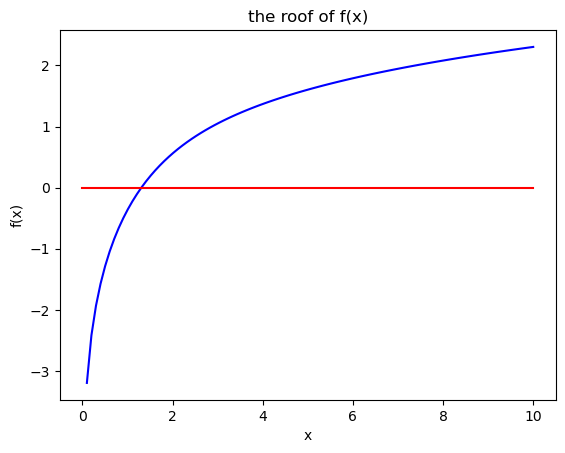

In [12]:
grid_x = np.linspace(0,10,100)
y = f1_func(grid_x)

fig, ax = plt.subplots()
ax.plot(grid_x,y, color='b')
ax.plot(grid_x, 0*grid_x, color='r' )
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('the roof of f(x)')
plt.show()


In [13]:
## Set an initial value
x0= 0.5  # initial value: we need to give an initial guess such 
         # the algorithm can start iterating to find the solution.

root_f1 = optimize.fsolve(f1_func, x0)
print('the root of the function is x*=', root_f1)


the root of the function is x*= [1.30979959]


#####  Example 2: Solow-Model (non-linear system of 3 equations)

In [16]:
# Parameter values
A=2
alpha=0.3
delta = 0.1
params = [A,alpha,delta]

#### Define the system of equations

In [18]:

def steady_state_ex2(s, params):
    # note that s is a vector with size 3: the three saving rates for each country.
    A,alpha,delta = params
    # from the Solow model we know that k* for each country k* is.
    k1 = (s[0]*A/delta)**(1/(1-alpha))
    k2 = (s[1]*A/delta)**(1/(1-alpha))
    k3 = (s[2]*A/delta)**(1/(1-alpha))
    
    # From the calibration, we know these equations need to be equal to 0 given s
    eq_1 = A*k2**(alpha) -1.2*A*k1**(alpha)
    eq_2 = A*k3**(alpha) -1.35*A*k1**(alpha)
    eq_3 = k3/(A*k3**(alpha))  - 3
    
    return  np.array([eq_1, eq_2, eq_3])

##### Set the system of equations for a single input: the vector s=s1,s2,s3 of saving rates




In [20]:
ss_func_ex2 = lambda s: steady_state_ex2(s,params)

Solve the system using fsolve. You might also try the routine optimize.root with the different methods.


In [22]:
s0= [0.1, 0.3, 0.5]  # initial value:   
root_savings = optimize.fsolve(ss_func_ex2, s0)
print('the saving rates s* of the 3 countries are')
print('s1 =',round(root_savings[0],2))
print('s2 =',round(root_savings[1],2))
print('s3 =',round(root_savings[2],2))

the saving rates s* of the 3 countries are
s1 = 0.15
s2 = 0.23
s3 = 0.3


#### Note that this exercise is tricky in the sense that s_i are bounded between (0,1). However, we were lucky and the results are between (0,1)

In [24]:
# trying for a different s0 ---you can check and observe that for some x0 the algorithm doesnt converge to the true solution
s0= [0.5, 0.5, 0.5]  # initial value

In [25]:
root_savings = optimize.fsolve(ss_func_ex2, s0)

print('The saving rates s* of each of the countries are')
print(root_savings)

The saving rates s* of each of the countries are
[0.14893924 0.22791104 0.3       ]


#  <center>Numerical Optimization

### Let's work with the rosenbrock function in 2-D to compare algorithms

## $$    \begin{equation*}
                f(\mathbf{x}) = f(x_1,x_2) = (1-x_1)^2+(x_2-x_1^2)^2
            \end{equation*}$$

In [28]:
def rosen_func_2d(x1, x2):
    
    return (1-x1)**2+(x2-x1**2)**2

In [29]:
# For a visual inspection, plot the function
x1_grid = np.linspace(-2,2,100)
x2_grid = np.linspace(-1,3,100)
X1, X2 =  np.meshgrid(x1_grid,x2_grid)
f_values = rosen_func_2d(X1, X2)

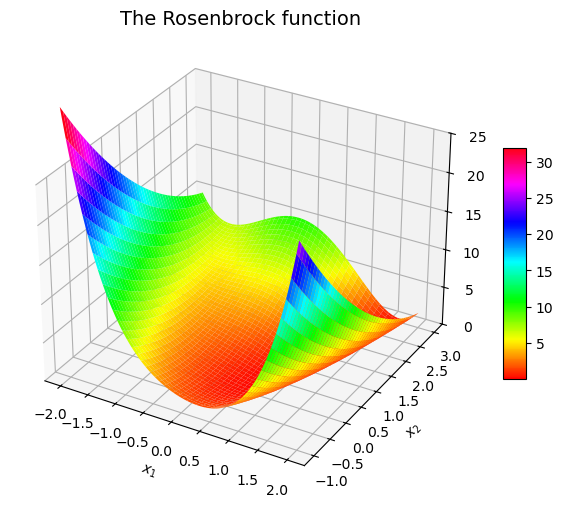

In [30]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X1, X2, f_values, cmap=cm.hsv)
ax.set_zlim(0, 25)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('The Rosenbrock function', fontsize=14)
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()


##### For minimization our function needs to be defined in terms of a single input: the vector of control variables (our old x)


In [32]:
def rosen_func(X):
    x1, x2 = X[0], X[1]
    return (1-x1)**2+(x2-x1**2)**2
    

##### Search Methods:

##### 1. Minimization using brute-force 


In [35]:
## we need to set the range of x1 and x2whre we want to create the grid.
ranges_X = ((-2,2),(-1,3))
#ranges_X = ((-10,10),(-10,10))  #try with another range.
print('Brute-force method ---------')
qe.tic()
res1 = optimize.brute(rosen_func, ranges_X)
qe.toc()
print(res1)

Brute-force method ---------
TOC: Elapsed: 0:00:0.00
[1.0000081  1.00002356]


##### Iterative Methods:

##### 2. Minimization using Quasi-Newton methods: BFGS

In [38]:
x0 = [0,0]
print('BFGS method ---------')
qe.tic()
res2 = optimize.minimize(rosen_func,x0) # also optimize.minimize(rosen_func,x0,method='BFGS') 
qe.toc()
print(res2.x)
# Not bad neither

# minimize provides us with a battery of outcomes including the jacobian, number of iterations, or
# whether the minimization was succesful.
print(res2)


BFGS method ---------
TOC: Elapsed: 0:00:0.00
[0.99999995 0.99999991]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.9986375725184793e-15
        x: [ 1.000e+00  1.000e+00]
      nit: 8
      jac: [-9.182e-08  4.548e-08]
 hess_inv: [[ 5.001e-01  9.993e-01]
            [ 9.993e-01  2.499e+00]]
     nfev: 30
     njev: 10


##### 3. Minimization using derivative-free methods: Nelder-Mead

In [40]:
x0 = [0,0]
print('Nelder-Mead method ---------')
qe.tic()
res3 = optimize.minimize(rosen_func,x0, method='nelder-mead') # also optimize.minimize(rosen_func,x0,method='BFGS') 
qe.toc()

print(res3.x)
# Not bad neither

print(res3)

Nelder-Mead method ---------
TOC: Elapsed: 0:00:0.01
[1.00001608 1.0000338 ]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.613059385742404e-10
             x: [ 1.000e+00  1.000e+00]
           nit: 67
          nfev: 129
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00]]), array([ 2.613e-10,  3.308e-10,  5.691e-10]))


### Rosenbrock function in 5-D

  ##   $$\sum_{i=1}^{N-1} (1-x_i)^2+(x_{i+1}-x_i^2)^2$$

In [42]:
# This function is quite ugly and can be simplified with a loop. You'll need to do that for PS4. 
def rosen_5d(X):    
    x1,x2,x3,x4,x5 = X
    return (1-X[0])**2+(X[1]-X[0]**2)**2  +(1-X[1])**2+(X[2]-X[1]**2)**2  +(1-X[2])**2+(X[3]-X[2]**2)**2 +(1-X[3])**2+(X[4]-X[3]**2)**2   


In [43]:
## Brute-force
ranges_X = ((-2,2),(-2,2),(-2,2),(-2,2),(-2,2))
print('Brute-force method ---------')
qe.tic()
res1 = optimize.brute(rosen_5d, ranges_X)
qe.toc()
print(res1)
# takes a bit of time


Brute-force method ---------
TOC: Elapsed: 0:00:17.16
[1.00002079 1.00002544 1.00002247 1.00002408 0.99997355]


In [44]:
# BFGS
x0 = [0,0,0,0,0]
print('BFGS method ---------')
qe.tic()
res2 = optimize.minimize(rosen_5d,x0)  
qe.toc()
print(res2.x)
# quite fast despite N=5

BFGS method ---------
TOC: Elapsed: 0:00:0.01
[1.00000009 1.00000017 1.0000001  0.99999985 0.99999952]


In [45]:
# Nelder-Mead
x0 = [0,0,0,0,0]
print('Nelder-Mead method ---------')
qe.tic()
res3 = optimize.minimize(rosen_5d,x0, method='nelder-mead')  
qe.toc()

Nelder-Mead method ---------
TOC: Elapsed: 0:00:0.02


0.025703907012939453

##### Bounded minimization of the Rosenbrock function --------------------


In [47]:
bnds = ((0.5, 2), (0.5, 2), (0.5, 2), (0.5, 2),(0.5, 2),)

##### L-BFGS-B

In [49]:

x0 = [0.5,0.5,0.5,0.5,0.5]
print('L-BFGS-B method ---------')
qe.tic()
res4 = optimize.minimize(rosen_5d,x0, method='L-BFGS-B', bounds=bnds) 
print(res4.x)
qe.toc()

L-BFGS-B method ---------
[0.99999988 0.99999977 1.00000012 0.99999977 0.99999919]
TOC: Elapsed: 0:00:0.02


0.02037525177001953

##### Powell

In [51]:

x0 = [0.5,0.5,0.5,0.5,0.5]
print('Powell method ---------')
qe.tic()
res5 = optimize.minimize(rosen_5d,x0, method='powell', bounds=bnds) 
print(res5.x)
qe.toc()


Powell method ---------
[1.00000004 1.00000034 1.         1.00000017 0.99999979]
TOC: Elapsed: 0:00:0.11


0.11064839363098145

#### Constrained minimization of the Rosenbrock function in N=2, constraint: 

####     $$\begin{align*}
              \underset{x_1,x_2}{\text{Min }} & (1-x_1)^2+(x_2-x_1^2)^2\\
                & \text{st: }  \\
               &  x_1^2+x_2^2 \leq 1
            \end{align*}$$

In [53]:
# we already computed the N=2 Rosenbrock function before: rosen_func
def rosen_func(X):
    x1, x2 = X[0], X[1]
    return (1-x1)**2+(x2-x1**2)**2

##### Define the constraint

In [55]:
def ineq_con(X):   
    return -(X[0]**2 + X[1]**2 -1)   
# inequality constraints are expressed in the form g(x)-b >= 0
# Thus we need to mulptiply by -1 our constraint.

In [56]:
# the constraint
cons = ({'type': 'ineq', 'fun': ineq_con  })

##### COBYLA method

In [58]:
qe.tic()
res1 = optimize.minimize(rosen_func,x0, method='COBYLA', constraints=cons) 
print(res1.x)
qe.toc()
# Succesful?
print(res1)

[0.80810667 0.58903619 0.48694279 0.50067708 0.55461313]
TOC: Elapsed: 0:00:0.00
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.0409190763312341
       x: [ 8.081e-01  5.890e-01  4.869e-01  5.007e-01  5.546e-01]
    nfev: 81
   maxcv: 1.7527397311312143e-08


##### SLSQP method

In [61]:
x0 = [0.5,0.5]
print('SLSQP method ---------')
qe.tic()
res2 = optimize.minimize(rosen_func,x0, method='SLSQP', constraints=cons) 
print(res2.x)
qe.toc()


SLSQP method ---------
[0.80816799 0.58895205]
TOC: Elapsed: 0:00:0.00


0.0030519962310791016

##### Trust Region constrained algoritm

In [63]:
x0 = [0.5,0.5]
print('trust-constr method ---------')
qe.tic()
res3 = optimize.minimize(rosen_func,x0, method='trust-constr', constraints=cons) 
print(res3.x)
qe.toc()


trust-constr method ---------
[0.80816657 0.58894402]
TOC: Elapsed: 0:00:0.04


0.0463261604309082

---

## Before the lab

- **Try it:** start BFGS and Nelder–Mead from `x0 = [-3, 3]` instead of `[0, 0]`. Which is more robust to a bad starting point? Count function evaluations.
- The 5-D Rosenbrock function written out by hand is ugly — rewriting it with a loop is part of [PS4](../psets/PS4_ECNM10115.pdf).
- Deeper slides: [Optimisation](../slides/Optimization_Autumn2025.pdf) and [Value Function Approximation](../slides/ValueFunctionApproximation.pdf).

*Next week: Numerical Methods II — optimisation in economic applications.*